In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train_df = pd.read_csv("../data/processed/train.csv")
print(train_df.shape)

(69608, 18)


### Column Types Classification

**ID (exclude from features):**
order_id, customer_id, customer_unique_id

**Numerical:**
num_items, total_price, total_freight, total_payment_value, num_payment_methods

**Categorical:**
order_status, customer_city, customer_state, customer_zip_code_prefix

**Date/Time:**
order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, 
order_delivered_customer_date, order_estimated_delivery_date

**Target:**
is_late

In [8]:
missing = train_df.isnull().sum()
missing_percent = (missing / len(train_df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

print(missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_percent", ascending=False))

                               missing_count  missing_percent
order_delivered_customer_date           2380         3.419147
order_delivered_carrier_date            1456         2.091714
num_items                                647         0.929491
total_price                              647         0.929491
total_freight                            647         0.929491
order_approved_at                         86         0.123549
total_payment_value                        1         0.001437
num_payment_methods                        1         0.001437


### Missing Values Summary

- `order_delivered_customer_date` (3.42%), `order_delivered_carrier_date` (2.09%): 
  Expected — orders not yet delivered/shipped (canceled, processing, etc.), 
  consistent with Task 1 findings.
- `num_items`, `total_price`, `total_freight` (0.93% each, same count): 
  **Caused by the left join in Notebook 1** — these orders exist in `orders` 
  but have no matching rows in `order_items`. Not original missingness. 
  To be handled in Notebook 5 (likely impute as 0 or investigate further).
- `order_approved_at` (0.12%), payment columns (~0.001%): minor, likely 
  canceled/edge-case orders.

In [9]:
numerical_cols = ["num_items", "total_price", "total_freight", "total_payment_value", "num_payment_methods"]
train_df[numerical_cols].describe()

,num_items,total_price,total_freight,total_payment_value,num_payment_methods
count,68961.000000,68961.000000,68961.000000,69607.000000,69607.000000
mean,1.141486,136.615566,22.288178,159.257369,1.048257
std,0.541285,206.374262,20.077747,216.625471,0.412692
min,1.000000,2.290000,0.000000,10.070000,1.000000
25%,1.000000,45.900000,14.100000,61.720000,1.000000
50%,1.000000,85.500000,16.790000,104.350000,1.000000
75%,1.000000,149.900000,23.700000,175.870000,1.000000
max,21.000000,13440.000000,1002.290000,13664.080000,29.000000


### Numerical Columns - Outliers Observed

- `total_price`: 75th percentile = 149.90, but max = 13,440.00 
  (~90x higher). Potential outlier — needs decision in Notebook 5 
  (keep, cap, or investigate individually).
- `num_payment_methods`: mean ≈ 1.05, but max = 29 payment installments 
  for a single order. Unusual — flagged for review in Notebook 5.
- Note: `.describe()` excludes NaN values automatically — counts here 
  (68,961 / 69,607) are lower than total train rows (69,608), consistent 
  with missing values found earlier.

In [10]:
categorical_cols = ["order_status", "customer_state", "customer_city"]

for col in categorical_cols:
    print(f"--- {col} ---")
    print(f"Number of unique values (cardinality): {train_df[col].nunique()}")
    print(train_df[col].value_counts().head(10))
    print()

--- order_status ---
Number of unique values (cardinality): 8
order_status
delivered      67224
shipped          855
unavailable      561
canceled         429
processing       290
invoiced         242
created            5
approved           2
Name: count, dtype: int64

--- customer_state ---
Number of unique values (cardinality): 27


customer_state
SP    28019
RJ     9343
MG     8333
RS     3997
PR     3545
SC     2645
BA     2400
ES     1468
GO     1456
DF     1444
Name: count, dtype: int64

--- customer_city ---
Number of unique values (cardinality): 3780
customer_city
sao paulo                10237
rio de janeiro            4989
belo horizonte            1924
brasilia                  1435
curitiba                  1043
porto alegre              1000
campinas                   990
salvador                   863
guarulhos                  749
sao bernardo do campo      641
Name: count, dtype: int64



### Categorical Columns Findings

- `order_status`: 99.7% "delivered". Non-delivered statuses 
  (canceled, processing, shipped...) overlap with missing delivery 
  dates found earlier — confirms these rows lack a valid label and 
  should be filtered out in Notebook 5, not just due to the left join.
- `customer_state`: 27 unique values, reasonable cardinality. 
  SP (São Paulo) dominates (~40%) — expected given its economic size.
- `customer_city`: 3,780 unique values — too high cardinality for 
  one-hot encoding (same issue as ID columns). `customer_state` is 
  a better feature choice for geography; `customer_city` will likely 
  be dropped or aggregated differently in Notebook 5.

In [11]:
# تحويل الأعمدة لتاريخ حقيقي (نفس المبدأ المتكرر)
train_df["order_purchase_timestamp"] = pd.to_datetime(train_df["order_purchase_timestamp"])
train_df["order_delivered_customer_date"] = pd.to_datetime(train_df["order_delivered_customer_date"])

# حساب مدة التوصيل الفعلية بالأيام (من الشراء للتسليم)
train_df["delivery_days"] = (train_df["order_delivered_customer_date"] - train_df["order_purchase_timestamp"]).dt.days

print(train_df["delivery_days"].describe())

count    67228.000000
mean        13.363286
std         10.254740
min          0.000000
25%          7.000000
50%         11.000000
75%         17.000000
max        209.000000
Name: delivery_days, dtype: float64


### Delivery Days Analysis

- Mean delivery time: ~13.4 days, Max: 209 days (clear outlier).
- `delivery_days` is derived from `order_delivered_customer_date`, 
  which is NOT available at prediction time (purchase moment). 
  **This column is for EDA/analysis only — must NOT be used as a 
  model feature (data leakage).**

### Safe Time-Based Features (for Notebook 5)

`order_purchase_timestamp` is known at prediction time — safe to 
extract: purchase month, weekday, hour. Unlike `delivery_days`, 
these carry seasonality/timing signal without leakage.

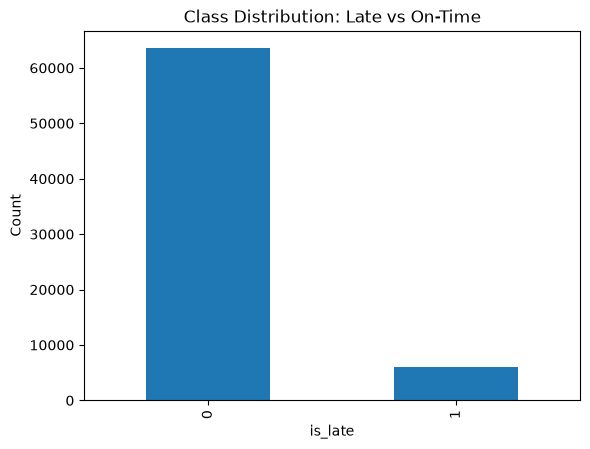

In [ ]:
train_df["is_late"].value_counts().plot(kind="bar", title="Class Distribution: Late vs On-Time")
plt.xlabel("is_late")
plt.ylabel("Count")
plt.savefig("../data/processed/class_distribution.png")
plt.show()